# LUPI 1D comparison: decoder-only task-ID vs. plain PFN bounds

Loads FOUR properly meta-trained checkpoints (each trained via the normal Hydra
pipeline, `ppfn.pipelines.train`, over many draws from `ppfn.prior.lupi`) and runs
ONE forward pass of each -- no gradient steps here, no per-instance fitting. This is
a genuine PFN posterior: in-context conditioning on one held-out 1D draw's data,
nothing more.

1. **PFN(A)** -- lower bound, `plain_pfn_bound_a_alone` checkpoint
   (`ppfn.model.baselines.plain_pfn_bounds.AAlonePlainPFN`): A's context alone.
2. **DECODER-TASKID([A,B])** -- `lupi_id_token` checkpoint's student pathway
   (`ppfn.model.baselines.lupi_id_token_pfn.LUPIIDTokenPFN`): pooled `[A_ctx, B]`,
   B raw (unregistered).
3. **Oracle Decoder([A,B_inA])** -- the SAME `lupi_id_token` checkpoint's teacher
   pathway: B repositioned via the true transport, value untouched (registration
   solved, value-distortion `h` still unsolved).
4. **PFN([A,B_inA])** -- `plain_pfn_bound_oracle` checkpoint
   (`ppfn.model.baselines.plain_pfn_bounds.OraclePlainPFN`): same oracle pooling,
   architecturally independent of panel 3 (no domain tag at all) -- a cross-check
   that panel 3's result is about the data, not the ID-token machinery.

Panels 2 and 3 come from ONE checkpoint (`lupi_id_token`) since the student and
teacher share one backbone by construction -- see that module's docstring.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from ppfn.prior.lupi.sampler import sample_pair
from ppfn.prior.lupi.dataset import LUPIBatch
from ppfn.model.baselines.lupi_id_token_pfn import LUPIIDTokenPFN
from ppfn.model.baselines.plain_pfn_bounds import AAlonePlainPFN, OraclePlainPFN

SEED = 9


## 1. Load the four checkpoints

Hyperparameters must match the real experiment configs exactly (`configs/model/
{lupi_id_token_pfn,plain_pfn_bound_a_alone,plain_pfn_bound_oracle}.yaml`) -- this
checkpoint scheme (`ppfn.callbacks.checkpoint.CheckpointCallback`) saves only
`model_state_dict`, no architecture config alongside it (see
`.claude/rules/checkpoints.md`), so the constructor args below are NOT
discoverable from the checkpoint file itself.

`CHECKPOINT_DIR` assumes this notebook is run on ulysses (or against a local sync
of `~/PycharmProjects/Meta_FTPFN/models/`) -- adjust if running elsewhere.

**Currently broken on purpose (2026-09-16), pending a retrain:** the
checkpoints on disk were trained under (a) `TailBarDistribution` (this
notebook's models now build `FullSupportBarDistribution` instead --
`ppfn.model.pfn.bar_distribution`'s module docstring) and (b) the old,
incorrect `enc_z`-paired oracle/teacher construction (now `enc_z_inA` --
`ppfn.prior.lupi.sampler.LUPIPair.z_b_inA`'s docstring). This cell, and
every cell after it that needs a loaded model, will error until the 4
experiments are re-run and their checkpoints overwritten. Section 2b below
(the prior depiction) needs no model and runs correctly regardless.

In [2]:
from pathlib import Path

CHECKPOINT_DIR = Path.home() / "PycharmProjects" / "Meta_FTPFN" / "models"

MODEL_KWARGS = dict(d_max=5, d_model=256, n_heads=8, n_layers=6, d_ff=512, n_bins_predictive=64)


def load_checkpoint(model, experiment_name):
    ckpt_path = CHECKPOINT_DIR / experiment_name / f"best_{experiment_name}.pt"
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"{experiment_name}: loaded epoch {ckpt['epoch']}, step {ckpt['global_step']}, "
          f"metrics at save: {ckpt['metrics']}")
    return model


model_a_alone = load_checkpoint(AAlonePlainPFN(**MODEL_KWARGS), "01-pretraining-plain-pfn-bound-a-alone")
model_lupi = load_checkpoint(LUPIIDTokenPFN(**MODEL_KWARGS), "01-pretraining-lupi-id-token")
model_oracle_plain = load_checkpoint(OraclePlainPFN(**MODEL_KWARGS), "01-pretraining-plain-pfn-bound-oracle")


RuntimeError: Error(s) in loading state_dict for AAlonePlainPFN:
	Missing key(s) in state_dict: "pfn.bar_dist.borders", "pfn.bar_dist.bucket_widths". 
	Unexpected key(s) in state_dict: "pfn.bar_dist.body.borders", "pfn.bar_dist.body.bucket_widths". 
	size mismatch for pfn.out_head.weight: copying a param with shape torch.Size([66, 256]) from checkpoint, the shape in current model is torch.Size([64, 256]).
	size mismatch for pfn.out_head.bias: copying a param with shape torch.Size([66]) from checkpoint, the shape in current model is torch.Size([64]).

## 2. One held-out 1D draw

Fresh draw, not used in training -- this is the "new task" a PFN conditions on
at inference time. `warp_grid_n=4` matches every training config's own override.

In [3]:
rng = np.random.default_rng(SEED)
pair, internals = sample_pair(
    rng, rho=0.5, d=1,
    n_a_range=(8, 15), n_b_range=(100, 150), n_qry_range=(100, 100),
    warp_grid_n=4, return_internals=True,
)
print(f"n_a_ctx={pair.x_a_ctx.shape[0]}  n_b={pair.x_b.shape[0]}  n_qry={pair.x_a_qry.shape[0]}")


n_a_ctx=9  n_b=143  n_qry=100


## 2b. What the prior draw actually looks like

Before any model touches it: the raw generative draw. Two panels, same `pair`/
`internals` as above, no predictions anywhere.

- **Left (A's frame, `Φ_0`)** -- what every model in this notebook is scored
  against. **A context** (white dots) is the acquisition-biased handful of
  points a model actually conditions on. **A query** (open triangles) is
  where `dec_qry_z` is actually scored -- these are real target draws from
  the prior, not the dense evaluation grid section 3 builds for plotting
  smooth curves. **B_inA (registered)** (filled blue) is B fully registered
  into A's frame -- position via `T` (`x_b_inA`) *and* value via `h`
  (`z_b_inA`) -- and sits right on the orange curve, up to B's own
  observation noise: this is exactly what a model should see if registration
  (both pieces) were fully solved, and it's what the *teacher*/oracle
  pathway is actually handed (`enc_x_inA`/`enc_z_inA`). **B, raw value**
  (faint blue outline, connected to its registered counterpart by a thin
  line) is the SAME point before `h` -- this is all the student ever sees;
  it never gets the registered version. The line length is `h`'s effect,
  isolated with position held fixed.

  Corrected 2026-09-16, at the user's direction: an earlier version of this
  notebook (and of the actual model code) mistakenly plotted/fed B_inA with
  the RAW value, so it sat off the curve by exactly `h`'s effect -- that
  made "registration solved" mean "position only," which breaks the
  intended meaning of distilling the student toward the teacher (the CE
  term is only a meaningful registration signal if the teacher itself
  represents registration being FULLY solved, T and h together). See
  `ppfn.prior.lupi.sampler.LUPIPair.z_b_inA`'s docstring.
- **Right (B's own frame, `Φ_ρ`)** -- B exactly as the student pathway
  receives it: its own coordinates (`x_b`), its own value scale (`z_b`, no
  `h`). The orange curve here is the undistorted `f(z)`, and B's points sit
  right on it (no gap) -- this is the ONLY view of B that ever reaches the
  student; everything registered is privileged, training-time-only
  information.

|x_b_inA - x_b| (T's effect on position): mean=0.0490 max=0.1142  (0 would mean no transport)
|z_b_inA - z_b| (h's effect on value, isolated): mean=0.4867 max=0.5236  (0 would mean h is the identity)


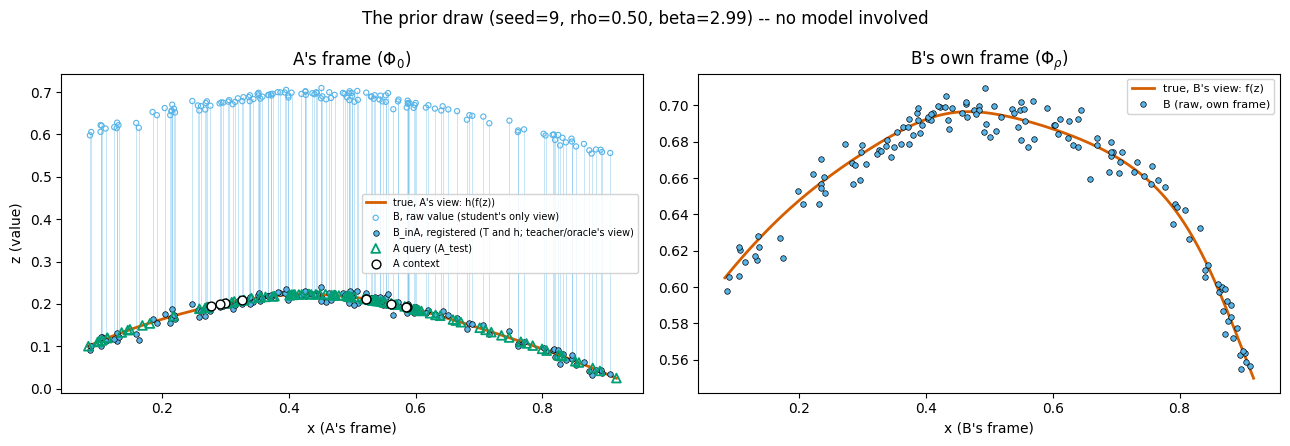

In [4]:
_zg = np.linspace(0.0, 1.0, 400).reshape(-1, 1)

# A's frame: h(f(z)) -- what A actually observes.
_xa = internals.to_a(_zg)[:, 0]
_ya = internals.true_value_as_a(_zg)
_oa = np.argsort(_xa)
_xa, _ya = _xa[_oa], _ya[_oa]

# B's own frame: f(z), no h -- what B actually observes.
_xb_true = internals.to_b(_zg)[:, 0]
_yb_true = internals.true_value_as_b(_zg)
_ob = np.argsort(_xb_true)
_xb_true, _yb_true = _xb_true[_ob], _yb_true[_ob]

warp_gap = np.abs(pair.x_b_inA[:, 0] - pair.x_b[:, 0])
print(f"|x_b_inA - x_b| (T's effect on position): mean={warp_gap.mean():.4f} max={warp_gap.max():.4f}  (0 would mean no transport)")

# z_b_inA = h(z_b): B's value recalibrated into A's scale -- pairs with
# x_b_inA for the FULLY registered oracle view (this is what enc_x_inA/
# enc_z_inA actually feed the teacher/oracle models). z_b (raw) is what the
# student always sees instead -- the line connecting each pair is h's
# effect on that point, isolated (position is identical on both ends).
h_gap = np.abs(pair.z_b_inA - pair.z_b)
print(f"|z_b_inA - z_b| (h's effect on value, isolated): mean={h_gap.mean():.4f} max={h_gap.max():.4f}  (0 would mean h is the identity)")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

axL.plot(_xa, _ya, color="#D55E00", lw=2, zorder=2, label="true, A's view: h(f(z))")
for xi, y_lo, y_hi in zip(pair.x_b_inA[:, 0], np.minimum(pair.z_b, pair.z_b_inA), np.maximum(pair.z_b, pair.z_b_inA)):
    axL.plot([xi, xi], [y_lo, y_hi], color="#56B4E9", lw=0.6, alpha=0.4, zorder=1)
axL.scatter(pair.x_b_inA[:, 0], pair.z_b, s=14, facecolor="none", edgecolor="#56B4E9",
            linewidth=0.8, zorder=3, label="B, raw value (student's only view)")
axL.scatter(pair.x_b_inA[:, 0], pair.z_b_inA, s=16, color="#56B4E9", edgecolor="black",
            linewidth=0.5, zorder=3, label="B_inA, registered (T and h; teacher/oracle's view)")
axL.scatter(pair.x_a_qry[:, 0], pair.z_a_qry, s=40, facecolor="none", edgecolor="#009E73",
            marker="^", linewidth=1.3, zorder=4, label="A query (A_test)")
axL.scatter(pair.x_a_ctx[:, 0], pair.z_a_ctx, s=40, color="white", edgecolor="black",
            zorder=5, label="A context")
axL.set_title("A's frame ($\\Phi_0$)")
axL.set_xlabel("x (A's frame)")
axL.set_ylabel("z (value)")
axL.legend(loc="best", fontsize=7, framealpha=0.85)

axR.plot(_xb_true, _yb_true, color="#D55E00", lw=2, zorder=2, label="true, B's view: f(z)")
axR.scatter(pair.x_b[:, 0], pair.z_b, s=16, color="#56B4E9", edgecolor="black",
            linewidth=0.5, zorder=3, label="B (raw, own frame)")
axR.set_title(r"B's own frame ($\Phi_\rho$)")
axR.set_xlabel("x (B's frame)")
axR.legend(loc="best", fontsize=8, framealpha=0.85)

fig.suptitle(f"The prior draw (seed={SEED}, rho={pair.rho:.2f}, beta={pair.beta:.2f}) -- no model involved")
fig.tight_layout()
plt.show()


### The combined view: A, B, and B_inA together, one axis, no queries

Both panels above split A's frame and B's own frame apart to keep the two
warps visually untangled. This one puts A, raw B, and registered B_inA on
the SAME axis instead -- x-position is plotted at face value for whichever
frame each point actually lives in, so B's raw dots land wherever `x_b`
(B's own frame) put them and B_inA's dots land wherever `x_b_inA` (A's
frame) put them. The point isn't that these are the same coordinate system
(they aren't, in general) -- it's to show, directly, how far a completely
unregistered B point sits from where it needs to be for A's model to use it
at all, and how registration (the line) closes that gap in one move.

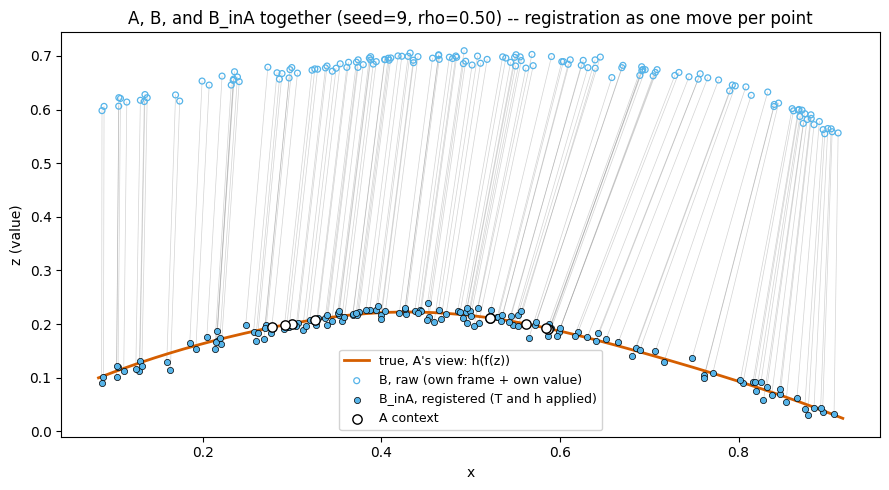

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(_xa, _ya, color="#D55E00", lw=2, zorder=2, label="true, A's view: h(f(z))")

for x0, x1, y0, y1 in zip(pair.x_b[:, 0], pair.x_b_inA[:, 0], pair.z_b, pair.z_b_inA):
    ax.plot([x0, x1], [y0, y1], color="gray", lw=0.5, alpha=0.35, zorder=1)

ax.scatter(pair.x_b[:, 0], pair.z_b, s=18, facecolor="none", edgecolor="#56B4E9",
           linewidth=0.9, zorder=3, label="B, raw (own frame + own value)")
ax.scatter(pair.x_b_inA[:, 0], pair.z_b_inA, s=20, color="#56B4E9", edgecolor="black",
           linewidth=0.5, zorder=4, label="B_inA, registered (T and h applied)")
ax.scatter(pair.x_a_ctx[:, 0], pair.z_a_ctx, s=45, color="white", edgecolor="black",
           zorder=5, label="A context")

ax.legend(loc="best", fontsize=9, framealpha=0.85)
ax.set_title(f"A, B, and B_inA together (seed={SEED}, rho={pair.rho:.2f}) -- registration as one move per point")
ax.set_xlabel("x")
ax.set_ylabel("z (value)")
fig.tight_layout()
plt.show()


## 3. Build a batch for the held-out draw, evaluated on a dense x-grid

In [6]:
from ppfn.prior.lupi.dataset import D_MAX, _pad_rescale_coords

def to_t(a):
    return torch.from_numpy(np.asarray(a, dtype=np.float32))


def _ones(n):
    return torch.ones(1, n, dtype=torch.bool)


# A real checkpoint's x_embed is Linear(D_MAX, d_model) -- every coordinate
# array must go through the SAME rescale-then-zero-pad the real training
# pipeline's collate_lupi_batch applies (_pad_rescale_coords), or the model
# sees a shape/scale it was never trained on. Missed this in an earlier
# version of this notebook (caught by a dry run against a dummy checkpoint
# before any real checkpoint existed -- see docs/labbook/).
def pad(x_np):
    return _pad_rescale_coords(x_np, d_real=pair.d, d_max=D_MAX)


X_GRID_1D = np.linspace(0.0, 1.0, 200).reshape(-1, 1).astype(np.float32)  # [n_grid, 1] -- pair.d==1 here


def grid_batch(pair, x_grid_1d):
    n_ctx, n_b, n_qry = pair.x_a_ctx.shape[0], pair.x_b.shape[0], x_grid_1d.shape[0]
    return LUPIBatch(
        enc_x=to_t(pad(pair.x_b)).view(1, n_b, D_MAX),
        enc_z=to_t(pair.z_b).view(1, n_b),
        enc_x_inA=to_t(pad(pair.x_b_inA)).view(1, n_b, D_MAX),
        # enc_z_inA: B's value recalibrated into A's SCALE via h -- pairs
        # with enc_x_inA for the fully-registered oracle view (both T and h
        # solved). NOT the same as enc_z (B's raw value): corrected
        # 2026-09-16 at the user's direction -- see LUPIPair.z_b_inA's
        # docstring for why pairing enc_x_inA with the unchanged enc_z was
        # wrong (the oracle would still have an unsolved value-calibration
        # problem, which breaks the CE-distillation signal's meaning).
        enc_z_inA=to_t(pair.z_b_inA).view(1, n_b),
        enc_mask=_ones(n_b),
        dec_ctx_x=to_t(pad(pair.x_a_ctx)).view(1, n_ctx, D_MAX),
        dec_ctx_z=to_t(pair.z_a_ctx).view(1, n_ctx),
        dec_ctx_oracle_bpos=to_t(pad(pair.oracle_bpos_a_ctx)).view(1, n_ctx, D_MAX),
        dec_ctx_mask=_ones(n_ctx),
        dec_qry_x=to_t(pad(x_grid_1d)).view(1, n_qry, D_MAX),
        dec_qry_z=torch.zeros(1, n_qry),
        dec_qry_oracle_bpos=torch.zeros(1, n_qry, D_MAX),
        dec_qry_mask=_ones(n_qry),
        dec_qry_source=torch.zeros(1, n_qry, dtype=torch.long),
        d_real=torch.tensor([pair.d]), rho=torch.tensor([pair.rho], dtype=torch.float32),
        beta=torch.tensor([pair.beta], dtype=torch.float32), meta=[pair.meta],
    )


batch = grid_batch(pair, X_GRID_1D)


## 4. One forward pass per model -- no training here

`model_a_alone`/`model_oracle_plain` return `{"predictive_logits"}` directly.
`model_lupi` (the `LUPIIDTokenPFN` wrapper) returns BOTH `student_logits`
(panel 2, `[A,B]` raw) and `teacher_logits` (panel 3, `[A,B_inA]`) from the same
call, since student and teacher share one backbone.

In [7]:
with torch.no_grad():
    logits_a_alone = model_a_alone(batch)["predictive_logits"][0]
    lupi_out = model_lupi(batch)
    logits_student = lupi_out["student_logits"][0]
    logits_teacher = lupi_out["teacher_logits"][0]
    logits_oracle_plain = model_oracle_plain(batch)["predictive_logits"][0]

bd_a_alone = model_a_alone.predictive_dist
bd_lupi = model_lupi.predictive_dist  # shared by student and teacher
bd_oracle_plain = model_oracle_plain.predictive_dist


NameError: name 'model_a_alone' is not defined

## 5. The column of 4 plots

In [8]:
z_grid = np.linspace(0.0, 1.0, 400).reshape(-1, 1)
x_true = internals.to_a(z_grid)[:, 0]
y_true = internals.true_value_as_a(z_grid)  # A's OWN (h-distorted) view of the true function
order = np.argsort(x_true)
x_true, y_true = x_true[order], y_true[order]

# Shared plotting range across all 4 panels, from what the models actually predict.
all_logits = [logits_a_alone, logits_student, logits_teacher, logits_oracle_plain]
all_bds = [bd_a_alone, bd_lupi, bd_lupi, bd_oracle_plain]
means = [bd.mean(lg).numpy() for bd, lg in zip(all_bds, all_logits)]
LO = min(float(np.min(m)) for m in means + [y_true]) - 1.0
HI = max(float(np.max(m)) for m in means + [y_true]) + 1.0

panels = [
    ("PFN(A)", bd_a_alone, logits_a_alone, pair.x_a_ctx[:, 0], pair.z_a_ctx, None, None),
    ("DECODER-TASKID([A,B])", bd_lupi, logits_student,
     pair.x_a_ctx[:, 0], pair.z_a_ctx, pair.x_b[:, 0], pair.z_b),
    ("Oracle Decoder([A,B_inA])", bd_lupi, logits_teacher,
     pair.x_a_ctx[:, 0], pair.z_a_ctx, pair.x_b_inA[:, 0], pair.z_b),
    ("PFN([A,B_inA])", bd_oracle_plain, logits_oracle_plain,
     pair.x_a_ctx[:, 0], pair.z_a_ctx, pair.x_b_inA[:, 0], pair.z_b),
]

# NOTE on the visualization choice: an earlier version of this cell plotted
# a density heatmap restricted to TailBarDistribution's BODY bins only
# (fixed range [-4,4] by construction, no top-level bucket_widths/variance/
# quantile exposed -- see that class). For this held-out draw the true
# values sit around z~4.5-5.5, i.e. almost entirely in the (unplotted)
# TAIL region -- the resulting heatmap was blank exactly where it mattered,
# which is a real finding about this checkpoint's fixed body range vs. this
# draw's actual scale, not just a plotting bug. Using the predictive MEAN
# (bd.mean(logits), which correctly integrates over body+tail) instead --
# less visually rich than a density map, but honest regardless of where
# the mass actually sits.
x_grid_plot = X_GRID_1D[:, 0]

fig, axes = plt.subplots(4, 1, figsize=(7, 12), sharex=True)
for ax, (title, bd, logits, xc, yc, xb, yb) in zip(axes, panels):
    pred_mean = bd.mean(logits).numpy()
    ax.plot(x_true, y_true, color="#D55E00", lw=2, zorder=2, label="true (A's view)")
    ax.plot(x_grid_plot, pred_mean, color="#2a78d6", lw=2, zorder=3, label="predictive mean")
    if xb is not None:
        ax.scatter(xb, yb, s=16, color="#56B4E9", edgecolor="black", linewidth=0.5,
                    zorder=4, label="B context")
    ax.scatter(xc, yc, s=30, color="white", edgecolor="black", zorder=5, label="A context")
    ax.legend(loc="best", fontsize=8, framealpha=0.85, ncol=2)
    ax.set_title(title)
    ax.set_ylabel("z (value)")
axes[-1].set_xlabel("x (A's frame)")
fig.tight_layout()
plt.show()


NameError: name 'logits_a_alone' is not defined

## Reading the panels

- **Panel 1 (PFN(A))**: only ever sees A's few context points.
- **Panel 2 (student)**: pooled `[A_ctx, B]`, B raw (blue dots on a different curve
  entirely, both position and value). Tests whether the additive-ID-token pooling
  keeps the model from being pulled toward B's band.
- **Panel 3 (oracle decoder)**: B's blue dots now sit at the correct x-position
  (true transport) but an uncorrected value -- isolates "T solved" from "h solved."
- **Panel 4 (plain PFN, oracle pooling)**: architecturally independent replication
  of panel 3's setup -- agreement between 3 and 4 means panel 3's result is about
  the data, not the ID-token architecture.

## 6. Ablation: what does the domain tag actually buy?

Same trained weights (`model_lupi.backbone`), same oracle-pooled data
(`[A_ctx ; B_inA]`) as panel 3 above -- the ONLY thing that changes is
`domain_ids`: normal (`id=0` for A, `id=1` for B_inA, as trained) vs. every
pooled token forced to `id=0` (the additive tag becomes a no-op, since
`domain_embed(0)` is added everywhere identically and stops carrying any
information). This isolates the tag's causal effect from everything else
(weights, data, architecture) held fixed -- not a retrained model, no new
checkpoint, just two forward passes.

In [9]:
import dataclasses

# Fully registered oracle batch: T (enc_x_inA) AND h (enc_z_inA) both
# applied -- same construction LUPIIDTokenPFN/OracleIDTokenPFN use for
# their teacher/oracle pathway (corrected 2026-09-16, see
# LUPIPair.z_b_inA's docstring: enc_z alone would leave h unsolved).
oracle_batch = dataclasses.replace(batch, enc_x=batch.enc_x_inA, enc_z=batch.enc_z_inA)

n_ctx = oracle_batch.dec_ctx_x.shape[1]
pooled_mask = torch.cat([oracle_batch.dec_ctx_mask, oracle_batch.enc_mask], dim=1)

domain_ids_tagged = pooled_mask.new_zeros(pooled_mask.shape, dtype=torch.long)
domain_ids_tagged[:, n_ctx:] = 1  # reproduces the trained teacher exactly

domain_ids_untagged = pooled_mask.new_zeros(pooled_mask.shape, dtype=torch.long)  # tag disabled: all id=0

with torch.no_grad():
    logits_tagged = model_lupi.backbone(oracle_batch, domain_ids_override=domain_ids_tagged)["predictive_logits"][0]
    logits_untagged = model_lupi.backbone(oracle_batch, domain_ids_override=domain_ids_untagged)["predictive_logits"][0]

# Sanity check: domain_ids_tagged must reproduce panel 3 (logits_teacher) exactly --
# same computation, just re-derived here instead of read from the earlier cell.
print("max |tagged - teacher| logits (~0 expected):", (logits_tagged - logits_teacher).abs().max().item())

pred_mean_tagged = bd_lupi.mean(logits_tagged).numpy()
pred_mean_untagged = bd_lupi.mean(logits_untagged).numpy()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_true, y_true, color="#D55E00", lw=2, zorder=2, label="true (A's view)")
ax.plot(x_grid_plot, pred_mean_tagged, color="#2a78d6", lw=2, zorder=4, label="tagged (as trained)")
ax.plot(x_grid_plot, pred_mean_untagged, color="#999999", lw=2, ls="--", zorder=3, label="tag disabled (id=0 everywhere)")
ax.scatter(pair.x_b_inA[:, 0], pair.z_b_inA, s=16, color="#56B4E9", edgecolor="black",
           linewidth=0.5, zorder=4, label="B_inA context (registered: T and h)")
ax.scatter(pair.x_a_ctx[:, 0], pair.z_a_ctx, s=30, color="white", edgecolor="black", zorder=5, label="A context")
ax.legend(loc="best", fontsize=8, framealpha=0.85, ncol=2)
ax.set_title("Same weights, same data -- domain tag on vs. forced off")
ax.set_xlabel("x (A's frame)")
ax.set_ylabel("z (value)")
fig.tight_layout()
plt.show()


NameError: name 'model_lupi' is not defined